In [1]:
'''
Graphene Corrosion Prediction using Machine Learning

Objective
To predict corrosion current density (Icorr) of graphene-coated copper
using structural parameters like defect ratio (ID/IG), layers, and defect density.

Approach
- Dataset creation (synthetic + research-based)
- Train ML models (Linear Regression, Random Forest)
- Compare models
- Predict corrosion behavior
'''

'\nGraphene Corrosion Prediction using Machine Learning\n\nObjective\nTo predict corrosion current density (Icorr) of graphene-coated copper\nusing structural parameters like defect ratio (ID/IG), layers, and defect density.\n\nApproach\n- Dataset creation (synthetic + research-based)\n- Train ML models (Linear Regression, Random Forest)\n- Compare models\n- Predict corrosion behavior\n'

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from pathlib import Path

df = pd.read_csv(Path("graphene_corrosion_final.csv"))

df.head()

,sample_id,ID_IG,Defect_Density,Wrinkle_Density,Layers,Interaction,Icorr
0,S0001,0.5695,141060000.0,1,1,1.410600e+08,16.9492
1,S0002,0.2902,71869000.0,1,2,1.437400e+08,0.3133
2,S0003,0.4499,111430000.0,2,4,4.457200e+08,1.0400
3,S0004,0.8067,199800000.0,3,6,1.198800e+09,0.8387
4,S0005,1.9150,474300000.0,3,8,3.794400e+09,1.3000


In [5]:
print(df.shape)
df.info()
df.describe()

(155, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        155 non-null    object 
 1   ID_IG            155 non-null    float64
 2   Defect_Density   155 non-null    float64
 3   Wrinkle_Density  155 non-null    int64  
 4   Layers           155 non-null    int64  
 5   Interaction      155 non-null    float64
 6   Icorr            155 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 8.6+ KB


,ID_IG,Defect_Density,Wrinkle_Density,Layers,Interaction,Icorr
count,155.000000,1.550000e+02,155.000000,155.000000,1.550000e+02,155.000000
mean,0.821749,2.035335e+08,2.206452,4.135484,1.127144e+09,4.131361
std,0.622661,1.542236e+08,0.819382,2.507333,1.387581e+09,6.723291
min,0.170600,4.225900e+07,1.000000,1.000000,6.406800e+07,0.229800
25%,0.400650,9.924150e+07,1.500000,2.000000,1.551150e+08,0.677850
50%,0.595400,1.474600e+08,2.000000,4.000000,4.401400e+08,1.040000
75%,0.905150,2.241900e+08,3.000000,6.000000,1.310700e+09,1.451450
max,2.807100,6.952800e+08,3.000000,9.000000,5.562200e+09,25.082000


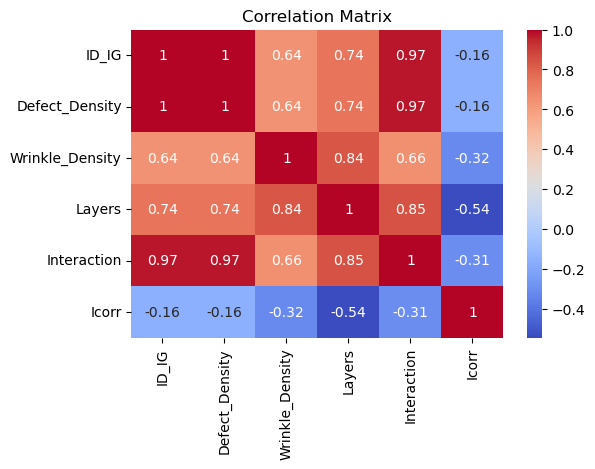

In [6]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

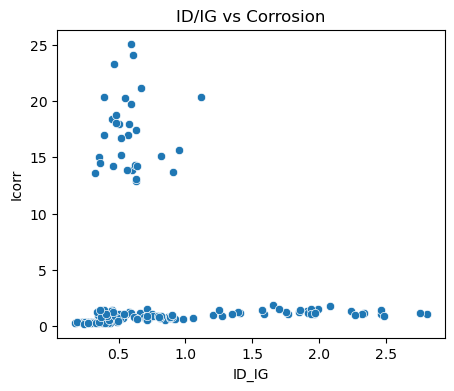

In [7]:
plt.figure(figsize=(5,4))
sns.scatterplot(x="ID_IG", y="Icorr", data=df)
plt.title("ID/IG vs Corrosion")
plt.show()

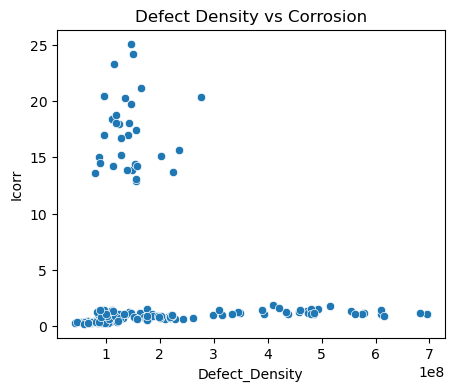

In [8]:
plt.figure(figsize=(5,4))
sns.scatterplot(x="Defect_Density", y="Icorr", data=df)
plt.title("Defect Density vs Corrosion")
plt.show()

In [9]:
# select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

X = numeric_df.drop("Icorr", axis=1)
y = numeric_df["Icorr"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (124, 5)
Test size: (31, 5)


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [14]:
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [15]:
def evaluate(name, y_test, y_pred):
    print(f"Model: {name}")
    print("R2 Score:", r2_score(y_test, y_pred))
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print("RMSE:", rmse)
    
    print("-" * 30)

In [16]:
evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("XGBoost", y_test, y_pred_xgb)

Model: Linear Regression
R2 Score: 0.3675235515416484
RMSE: 6.486278825894262
------------------------------
Model: Random Forest
R2 Score: 0.761458739137602
RMSE: 3.9834116561651225
------------------------------
Model: XGBoost
R2 Score: 0.6399409163893142
RMSE: 4.893958930953053
------------------------------


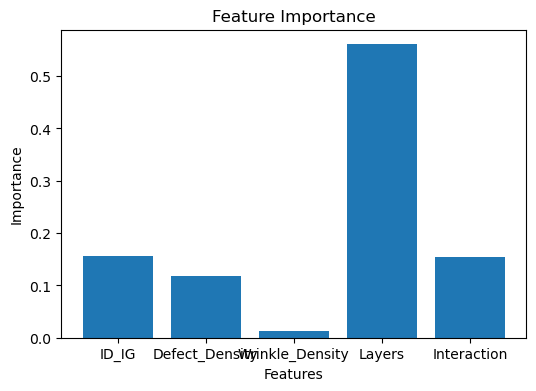

In [17]:
importances = rf.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [18]:
def predict_corrosion(ID_IG, layers, defect_density, wrinkle_density):
    
    interaction = ID_IG * defect_density   # IMPORTANT
    
    input_data = [[ID_IG, defect_density, wrinkle_density, layers, interaction]]
    
    return rf.predict(input_data)[0]

In [21]:
result = predict_corrosion(0.3, 2, 0.4, 0.2)
print("Predicted Corrosion:", result)

Predicted Corrosion: 0.3076960000000002


In [22]:
import pandas as pd
import numpy as np

# Fix other parameters (keep them constant)
ID_IG = 0.3
defect_density = 0.4
wrinkle_density = 0.2

layers_list = [1, 2, 3, 4, 6, 8]

results = []

for layer in layers_list:
    
    interaction = ID_IG * defect_density
    
    input_data = [[ID_IG, defect_density, wrinkle_density, layer, interaction]]
    
    prediction = rf.predict(input_data)[0]
    
    results.append([layer, prediction])

df_layers = pd.DataFrame(results, columns=["Layers", "Predicted_Icorr"])

df_layers

,Layers,Predicted_Icorr
0,1,0.902895
1,2,0.307696
2,3,0.362207
3,4,0.421643
4,6,0.421643
5,8,0.427560


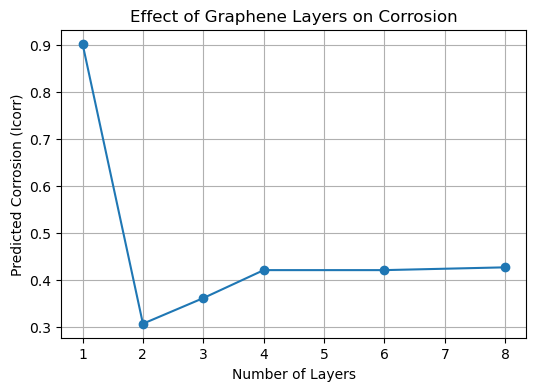

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(df_layers["Layers"], df_layers["Predicted_Icorr"], marker='o')

plt.xlabel("Number of Layers")
plt.ylabel("Predicted Corrosion (Icorr)")
plt.title("Effect of Graphene Layers on Corrosion")

plt.grid()
plt.show()

In [24]:
best_layer = df_layers.loc[df_layers["Predicted_Icorr"].idxmin()]

print("Best Layer:")
print(best_layer)

Best Layer:
Layers             2.000000
Predicted_Icorr    0.307696
Name: 1, dtype: float64


In [25]:
df_layers["Category"] = df_layers["Layers"].apply(lambda x: "2-Layer" if x == 2 else "Other")

grouped = df_layers.groupby("Category")["Predicted_Icorr"].mean()

print(grouped)

Category
2-Layer    0.307696
Other      0.507190
Name: Predicted_Icorr, dtype: float64


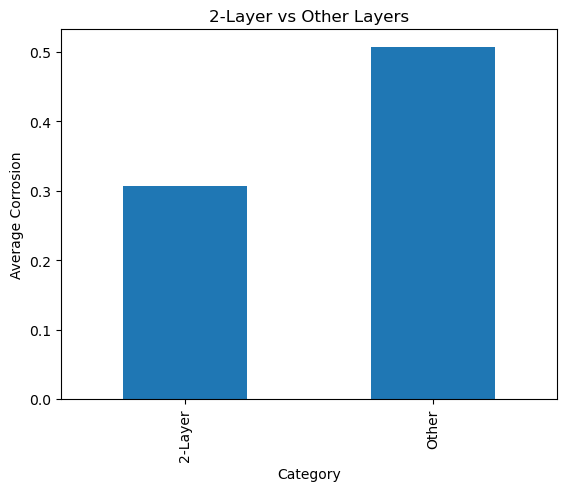

In [26]:
grouped.plot(kind='bar')

plt.title("2-Layer vs Other Layers")
plt.ylabel("Average Corrosion")
plt.show()